<a href="https://colab.research.google.com/github/NorkulovAzim/colab-intro-notebook/blob/main/Weight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Car Weight with Linear Regression

This notebook builds a small, reproducible regression model that estimates a car's **weight in pounds** from its fuel efficiency and technical specifications. It uses real observations from UCI's Auto MPG dataset, compares the model with a mean-only baseline, evaluates held-out predictions, and visualizes the results.

> This is an educational exercise using historical data—not a tool for vehicle safety, engineering, or purchase decisions.

## 1. Load the dataset

The UCI Auto MPG dataset contains 398 cars and includes fuel economy, cylinders, engine displacement, horsepower, weight, acceleration, model year, origin, and car name. Six records have unknown horsepower; those rows are omitted for this analysis. The dataset dates from the 1970s and early 1980s, so it should not be treated as representative of modern vehicles.

In [1]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import shlex

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_URL = "https://archive.ics.uci.edu/static/public/9/auto+mpg.zip"

response = urlopen(DATA_URL, timeout=30)
with ZipFile(BytesIO(response.read())) as archive:
    raw_text = archive.read("auto-mpg.data").decode("utf-8")

columns = [
    "mpg", "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model_year", "origin", "car_name",
]
rows = [shlex.split(line) for line in raw_text.splitlines() if line.strip()]
raw = pd.DataFrame(rows, columns=columns)

numeric_columns = columns[:-1]
for column in numeric_columns:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

print(f"Downloaded {len(raw)} records from UCI.")
print(f"Unknown horsepower values: {raw['horsepower'].isna().sum()}")
print(raw.head().to_string(index=False))

Downloaded 398 records from UCI.
Unknown horsepower values: 6
 mpg  cylinders  displacement  horsepower  weight  acceleration  model_year  origin                  car_name
18.0          8         307.0       130.0  3504.0          12.0          70       1 chevrolet chevelle malibu
15.0          8         350.0       165.0  3693.0          11.5          70       1         buick skylark 320
18.0          8         318.0       150.0  3436.0          11.0          70       1        plymouth satellite
16.0          8         304.0       150.0  3433.0          12.0          70       1             amc rebel sst
17.0          8         302.0       140.0  3449.0          10.5          70       1               ford torino

## 2. Choose the target and features

The target is `weight` (pounds). We use six numeric predictors: `mpg`, `cylinders`, `displacement`, `horsepower`, `acceleration`, and `model_year`. The `origin` field is a numeric category code rather than a measured quantity, so it is deliberately excluded instead of treating its codes as an ordered scale. The car name is an identifier and is also excluded.

In [2]:
FEATURES = [
    "mpg", "cylinders", "displacement", "horsepower",
    "acceleration", "model_year",
]
TARGET = "weight"

model_data = raw[FEATURES + [TARGET]].dropna().copy()
print(f"Rows retained for modeling: {len(model_data)} of {len(raw)}")
print("Target summary (pounds):")
print(model_data[TARGET].describe().round(1).to_string())

Rows retained for modeling: 392 of 398
Target summary (pounds):
count     392.0
mean     2977.6
std       849.4
min      1613.0
25%      2225.2
50%      2803.5
75%      3614.8
max      5140.0

## 3. Split the data and fit a linear model

We reserve 20% of the rows for testing. The split is shuffled with a fixed random seed so it is repeatable. Predictors are standardized using **training-set** means and standard deviations only; the model coefficients are then found with NumPy's least-squares solver. An intercept is included.

In [3]:
rng = np.random.default_rng(42)
order = rng.permutation(len(model_data))
split_at = int(0.8 * len(order))
train = model_data.iloc[order[:split_at]]
test = model_data.iloc[order[split_at:]]

X_train_raw = train[FEATURES].to_numpy(dtype=float)
X_test_raw = test[FEATURES].to_numpy(dtype=float)
y_train = train[TARGET].to_numpy(dtype=float)
y_test = test[TARGET].to_numpy(dtype=float)

feature_means = X_train_raw.mean(axis=0)
feature_stds = X_train_raw.std(axis=0)
feature_stds[feature_stds == 0] = 1.0
X_train = (X_train_raw - feature_means) / feature_stds
X_test = (X_test_raw - feature_means) / feature_stds

train_design = np.column_stack([np.ones(len(X_train)), X_train])
test_design = np.column_stack([np.ones(len(X_test)), X_test])
coefficients, *_ = np.linalg.lstsq(train_design, y_train, rcond=None)
y_pred = test_design @ coefficients

print(f"Training rows: {len(train)} | Test rows: {len(test)}")
print("Model fitted successfully.")

Training rows: 313 | Test rows: 79
Model fitted successfully.

## 4. Evaluate against a simple baseline

We compare the regression with a baseline that predicts the training-set average weight for every test car. **MAE** and **RMSE** are in pounds; lower is better. **R²** measures the fraction of test-set variation explained relative to predicting the test-set mean.

In [4]:
def regression_metrics(actual, predicted):
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    denominator = np.sum((actual - actual.mean()) ** 2)
    r2 = 1 - np.sum((actual - predicted) ** 2) / denominator
    return {"MAE (lb)": mae, "RMSE (lb)": rmse, "R²": r2}

baseline_pred = np.full(len(y_test), y_train.mean())
results = pd.DataFrame(
    [regression_metrics(y_test, y_pred), regression_metrics(y_test, baseline_pred)],
    index=["Linear regression", "Mean baseline"],
)
print(results.round(3).to_string())

                   MAE (lb)  RMSE (lb)     R²
Linear regression   183.656    254.035  0.916
Mean baseline       722.142    881.282 -0.005

,MAE (lb),RMSE (lb),R²
Linear regression,183.656,254.035,0.916
Mean baseline,722.142,881.282,-0.005


## 5. Inspect the fitted coefficients

The feature values were standardized before fitting, so each coefficient describes the estimated change in weight (pounds) associated with a one-standard-deviation change in that feature, holding the other included features fixed. These are associations in this dataset, not causal effects.

In [5]:
coefficient_table = pd.DataFrame({
    "feature": FEATURES,
    "coefficient (lb per feature SD)": coefficients[1:],
})
coefficient_table["absolute coefficient"] = coefficient_table["coefficient (lb per feature SD)"].abs()
coefficient_table = coefficient_table.sort_values("absolute coefficient", ascending=False)
print(coefficient_table.drop(columns="absolute coefficient").round(2).to_string(index=False))

     feature  coefficient (lb per feature SD)
displacement                           403.59
  horsepower                           276.31
         mpg                          -257.61
acceleration                           166.78
  model_year                           126.50
   cylinders                            65.90

feature,coefficient (lb per feature SD)
displacement,403.59
horsepower,276.31
mpg,-257.61
acceleration,166.78
model_year,126.50
cylinders,65.90


## 6. Compare predictions with actual weights

Points closer to the dashed diagonal are better predictions. Because the test set is small and historical, the chart is a teaching aid rather than a guarantee of performance on other vehicles.

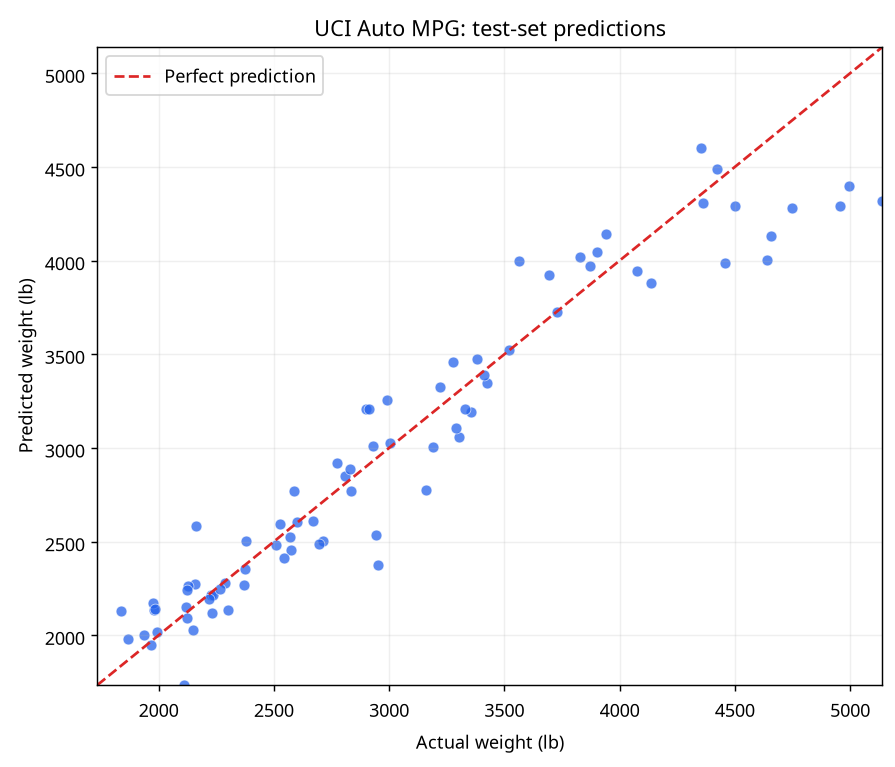

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.75, color="#2563eb", edgecolor="white", linewidth=0.4)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, linestyle="--", color="#dc2626", label="Perfect prediction")
ax.set(xlim=limits, ylim=limits, xlabel="Actual weight (lb)", ylabel="Predicted weight (lb)",
       title="UCI Auto MPG: test-set predictions")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

## 7. Try one example prediction

This example is illustrative. It is not a specific real vehicle record; it shows how to apply the trained model to a row with the same six features.

In [7]:
example = pd.DataFrame([{
    "mpg": 25.0,
    "cylinders": 4,
    "displacement": 140.0,
    "horsepower": 90.0,
    "acceleration": 15.0,
    "model_year": 80,
}], columns=FEATURES)
example_scaled = (example.to_numpy(dtype=float) - feature_means) / feature_stds
example_design = np.column_stack([np.ones(len(example_scaled)), example_scaled])
predicted_weight = float((example_design @ coefficients)[0])
print(f"Estimated weight: {predicted_weight:,.0f} lb")

Estimated weight: 2,655 lb

## Notes and source

- The dataset contains historical vehicle observations; relationships may not generalize to newer vehicles.
- Linear regression is sensitive to outliers and correlated predictors. A strong test score on this small dataset is not a guarantee for individual vehicles.
- **Source:** Quinlan, R. (1993). *Auto MPG* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5859H](https://doi.org/10.24432/C5859H).
- UCI lists the dataset under **CC BY 4.0**. Dataset details and files: [UCI Auto MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg).